# Evaluating GPT-3 / BART, BERT, and RoBERTa for Sentiment Classification in Social Media Text

### Team Project — Natural Language Processing

---
### Before Running:
1. Go to **Runtime → Change runtime type → Hardware accelerator → T4 GPU**
2. After Section 1 installs libraries, go to **Runtime → Restart session**, then continue from Section 2
---

## Section 1: Install Libraries

In [ ]:
# Install libraries for openAI and httpx
!pip install -q "openai>=1.30.0" "httpx>=0.27.1,<1.0.0"

In [ ]:
# Install pinned versions to avoid compatibility issues on Colab
!pip install -q transformers==4.36.0
!pip install -q datasets==2.16.0
!pip install -q torch
!pip install -q scikit-learn pandas numpy matplotlib seaborn tqdm
print('Installation complete!')

Installation complete!


## Section 2: Import Libraries

In [ ]:
import re
import time
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm

import torch
from torch.utils.data import DataLoader, TensorDataset
from torch.optim import AdamW
from torch.optim.lr_scheduler import LinearLR

import transformers
print(f'Transformers version: {transformers.__version__}')

from transformers import (
    BertTokenizer,
    BertForSequenceClassification,
    RobertaTokenizer,
    RobertaForSequenceClassification,
    get_linear_schedule_with_warmup
)
from datasets import load_dataset

from sklearn.metrics import (
    accuracy_score, precision_score,
    recall_score, f1_score,
    classification_report, confusion_matrix
)

import openai

# ── Global settings ──
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
MAX_LEN = 64      # Tweets are short; 64 tokens is sufficient and faster than 128
BATCH_SIZE = 32
EPOCHS = 2         # 2 epochs is enough for fine-tuning on this dataset
NUM_LABELS = 3
SEED = 42
TRAIN_SAMPLE = 3000    # Use subset for faster training; increase if you have time
TEST_SAMPLE = 1000    # Use subset for evaluation
GPT3_SAMPLE = 100     # Keep small to manage API cost
YELP_SAMPLE  = 3000

torch.manual_seed(SEED)
np.random.seed(SEED)

print(f'All libraries imported successfully!')
print(f'Device: {DEVICE}')
print(f'GPU available: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU name: {torch.cuda.get_device_name(0)}')

Transformers version: 4.36.0
All libraries imported successfully!
Device: cuda
GPU available: True
GPU name: Tesla T4


## Section 3: Load & Explore Dataset

In [ ]:
# Load TweetEval sentiment dataset (SemEval-based Twitter benchmark)
# Labels: 0 = Negative, 1 = Neutral, 2 = Positive
print('Loading dataset...')
dataset = load_dataset('tweet_eval', 'sentiment', trust_remote_code=True)

tweet_train_df = pd.DataFrame(dataset['train'])
tweet_test_df = pd.DataFrame(dataset['test'])
val_df = pd.DataFrame(dataset['validation'])

label_map = {0: 'Negative', 1: 'Neutral', 2: 'Positive'}
for df in [tweet_train_df, tweet_test_df, val_df]:
    df['label_name'] = df['label'].map(label_map)

print(f'Full Train size : {len(tweet_train_df)}')
print(f'Full Test size  : {len(tweet_test_df)}')
print(f'Full Val size   : {len(val_df)}')

# Use stratified subsets for faster training
tweet_train_df = tweet_train_df.groupby('label', group_keys=False).apply(
    lambda x: x.sample(min(len(x), TRAIN_SAMPLE // NUM_LABELS), random_state=SEED)
).reset_index(drop=True)

tweet_test_df = tweet_test_df.groupby('label', group_keys=False).apply(
    lambda x: x.sample(min(len(x), TEST_SAMPLE // NUM_LABELS), random_state=SEED)
).reset_index(drop=True)

val_df = val_df.groupby('label', group_keys=False).apply(
    lambda x: x.sample(min(len(x), TEST_SAMPLE // NUM_LABELS), random_state=SEED)
).reset_index(drop=True)

print(f'\nSampled Train size: {len(tweet_train_df)}')
print(f'Sampled Test size: {len(tweet_test_df)}')
print(f'Sampled Val size: {len(val_df)}')
tweet_train_df.head()

Loading dataset...
Full Train size : 45615
Full Test size  : 12284
Full Val size   : 2000

Sampled Train size: 3000
Sampled Test size: 999
Sampled Val size: 978


,text,label,label_name
0,"""#CNET - Just bought my 1st iPad, iPad3, feeli...",0,Negative
1,"""Mother's Day is coming like tomorrow or is it...",0,Negative
2,Can't believe I left my charger at Tia's. I ha...,0,Negative
3,If I didn't yell at someone about Taylor Swift...,0,Negative
4,@user @user Nice Try - but why do you #LIE! (#...,0,Negative


In [ ]:
print('Loading Yelp Review dataset...')
yelp_dataset = load_dataset('yelp_review_full', trust_remote_code=True)

yelp_train_df = pd.DataFrame(yelp_dataset['train'])
yelp_test_df  = pd.DataFrame(yelp_dataset['test'])

# Map Yelp star ratings (0-indexed: 0=1star ... 4=5stars) to sentiment labels
# yelp_review_full stores stars as 0–4 (i.e. actual stars minus 1)
def map_yelp_label(star):
    """Map Yelp star rating (0-indexed) to sentiment: 0=Neg, 1=Neu, 2=Pos."""
    if star <= 1:   return 0   # 1–2 stars → Negative
    elif star == 2: return 1   # 3 stars   → Neutral
    else:           return 2   # 4–5 stars → Positive

yelp_train_df['label']      = yelp_train_df['label'].apply(map_yelp_label)
yelp_test_df['label']       = yelp_test_df['label'].apply(map_yelp_label)
yelp_train_df['label_name'] = yelp_train_df['label'].map(label_map)
yelp_test_df['label_name']  = yelp_test_df['label'].map(label_map)
yelp_train_df['source']     = 'yelp'
yelp_test_df['source']      = 'yelp'

# Rename Yelp text column to match TweetEval ('text')
yelp_train_df = yelp_train_df.rename(columns={'text': 'text'})

# Stratified sample from Yelp
yelp_train_df = yelp_train_df.groupby('label', group_keys=False).apply(
    lambda x: x.sample(min(len(x), YELP_SAMPLE // NUM_LABELS), random_state=SEED)
).reset_index(drop=True)

yelp_test_df = yelp_test_df.groupby('label', group_keys=False).apply(
    lambda x: x.sample(min(len(x), TEST_SAMPLE // NUM_LABELS), random_state=SEED)
).reset_index(drop=True)

print(f'Sampled Yelp     — Train: {len(yelp_train_df)} | Test: {len(yelp_test_df)}')

Loading Yelp Review dataset...
Sampled Yelp     — Train: 3000 | Test: 999


In [ ]:
tweet_train_df['source'] = 'twitter'
tweet_test_df['source']  = 'twitter'
yelp_train_df['source']  = 'yelp'
yelp_test_df['source']   = 'yelp'

train_df = pd.concat([tweet_train_df, yelp_train_df], ignore_index=True).sample(
    frac=1, random_state=SEED   # shuffle combined training set
).reset_index(drop=True)

test_df = pd.concat([tweet_test_df, yelp_test_df], ignore_index=True).sample(
    frac=1, random_state=SEED
).reset_index(drop=True)

print(f'\nCombined Train size: {len(train_df)}')
print(f'Combined Val size: {len(val_df)}  (TweetEval only — used for loss monitoring)')
print(f'Combined Test size: {len(test_df)}')
print(f'\nTrain source breakdown:\n{train_df["source"].value_counts().to_string()}')
print(f'\nTest source breakdown:\n{test_df["source"].value_counts().to_string()}')


Combined Train size: 6000
Combined Val size: 978  (TweetEval only — used for loss monitoring)
Combined Test size: 1998

Train source breakdown:
source
twitter    3000
yelp       3000

Test source breakdown:
source
twitter    999
yelp       999


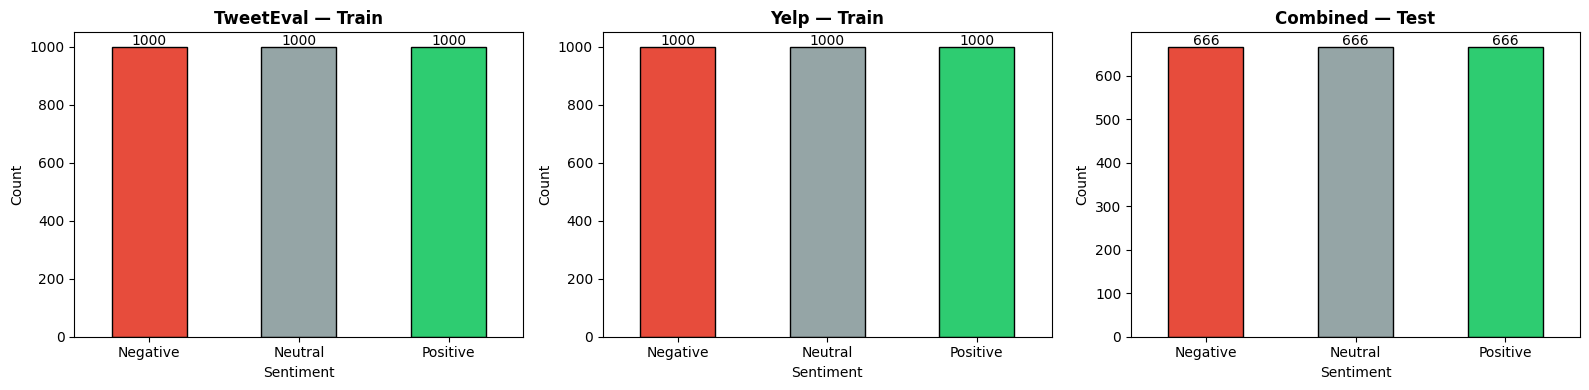

Label distribution saved.


In [ ]:
# Visualize label distribution
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
colors = ['#e74c3c', '#95a5a6', '#2ecc71']

plot_pairs = [
    (tweet_train_df, 'TweetEval — Train'),
    (yelp_train_df,  'Yelp — Train'),
    (test_df,        'Combined — Test'),
]

for ax, (df, title) in zip(axes, plot_pairs):
    counts = df['label_name'].value_counts().reindex(['Negative', 'Neutral', 'Positive'])
    counts.plot(kind='bar', ax=ax, color=colors, edgecolor='black')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Sentiment')
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=0)
    for p in ax.patches:
        ax.annotate(str(int(p.get_height())),
                    (p.get_x() + p.get_width() / 2, p.get_height() + 5),
                    ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('label_distribution.png', dpi=150)
plt.show()
print('Label distribution saved.')

## Section 4: Data Preprocessing

In [ ]:
def preprocess_tweet(text):
    """Clean and normalize text for model input (works for both tweets and reviews)."""
    text = re.sub(r'http\S+|www\S+', '', text)      # Remove URLs
    text = re.sub(r'@\w+', '', text)                 # Remove mentions (Twitter)
    text = re.sub(r'#(\w+)', r'\1', text)            # Remove # but keep word (Twitter)
    text = re.sub(r'[^a-zA-Z\s!?.,]', '', text)     # Keep letters and punctuation
    text = re.sub(r'\s+', ' ', text).strip()         # Normalize whitespace
    return text.lower()

for df in [train_df, val_df, test_df]:
    df['clean_text'] = df['text'].apply(preprocess_tweet)
    df['clean_text'] = df['clean_text'].replace('', 'empty')

print('Preprocessing complete.')
print('\nTweet sample:')
tweet_row = train_df[train_df['source'] == 'twitter'].iloc[0]
print(f'Original: {tweet_row["text"]}')
print(f'Cleaned: {tweet_row["clean_text"]}')
print('\nYelp sample:')
yelp_row = train_df[train_df['source'] == 'yelp'].iloc[0]
print(f'Original: {yelp_row["text"][:120]}...')
print(f'Cleaned: {yelp_row["clean_text"][:120]}...')

Preprocessing complete.

Tweet sample:
Original: "Lady Gaga - ""Applause"" - Empire of the Sun Remix my new single #MTVStarOf2015 Lady Gaga
Cleaned: lady gaga applause empire of the sun remix my new single mtvstarof lady gaga

Yelp sample:
Original: Wow.  That didn't last long.  Six months ago we were all praising Federico's and pleased that Scottsdale finally has a g...
Cleaned: wow. that didnt last long. six months ago we were all praising federicos and pleased that scottsdale finally has a great...


## Section 5: Shared Tokenization & Training Utilities

In [ ]:
def build_dataset(texts, labels, tokenizer):
    """Tokenize texts and return a TensorDataset."""
    enc = tokenizer(
        list(texts),
        truncation=True,
        padding='max_length',
        max_length=MAX_LEN,
        return_tensors='pt'
    )
    return TensorDataset(
        enc['input_ids'],
        enc['attention_mask'],
        torch.tensor(list(labels), dtype=torch.long)
    )


def train_model(model, train_loader, val_loader, optimizer, scheduler):
    """Fine-tune model for EPOCHS epochs with train and val loss tracking."""
    model.train()
    history = []
    for epoch in range(EPOCHS):
        # Training
        model.train()
        total_loss, steps = 0, 0
        for batch in tqdm(train_loader, desc=f'Epoch {epoch+1}/{EPOCHS} [Train]'):
            input_ids, attention_mask, labels = [b.to(DEVICE) for b in batch]
            optimizer.zero_grad()
            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )
            outputs.loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()
            total_loss += outputs.loss.item()
            steps += 1
        avg_train_loss = total_loss / steps

        # Validation
        model.eval()
        val_loss, val_steps = 0, 0
        with torch.no_grad():
            for batch in tqdm(val_loader, desc=f'Epoch {epoch+1}/{EPOCHS} [Val]'):
                input_ids, attention_mask, labels = [b.to(DEVICE) for b in batch]
                outputs = model(
                    input_ids=input_ids,
                    attention_mask=attention_mask,
                    labels=labels
                )
                val_loss += outputs.loss.item()
                val_steps += 1
        avg_val_loss = val_loss / val_steps

        history.append({'train': avg_train_loss, 'val': avg_val_loss})
        print(f'  → Epoch {epoch+1} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}')
    return history


def evaluate_model(model, test_loader, model_name='Model'):
    """Evaluate model and return metrics dict."""
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for batch in tqdm(test_loader, desc=f'Evaluating {model_name}'):
            input_ids, attention_mask, labels = [b.to(DEVICE) for b in batch]
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            preds = torch.argmax(outputs.logits, dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.cpu().numpy())

    acc  = accuracy_score(all_labels, all_preds)
    prec = precision_score(all_labels, all_preds, average='macro', zero_division=0)
    rec  = recall_score(all_labels, all_preds, average='macro', zero_division=0)
    f1   = f1_score(all_labels, all_preds, average='macro', zero_division=0)

    print(f'\n{model_name} Results:')
    print(f'   Accuracy  : {acc:.4f}')
    print(f'   Precision : {prec:.4f}')
    print(f'   Recall    : {rec:.4f}')
    print(f'   Macro-F1  : {f1:.4f}')
    print(classification_report(
        all_labels, all_preds,
        target_names=['Negative', 'Neutral', 'Positive']
    ))
    return {
        'accuracy': acc, 'precision': prec,
        'recall': rec, 'f1': f1,
        'preds': all_preds, 'labels': all_labels
    }

def compute_metrics(labels, preds, name):
    """Compute and print classification metrics."""
    acc  = accuracy_score(labels, preds)
    prec = precision_score(labels, preds, average='macro', zero_division=0)
    rec  = recall_score(labels, preds, average='macro', zero_division=0)
    f1   = f1_score(labels, preds, average='macro', zero_division=0)
    print(f'\n{name}:')
    print(f'Accuracy: {acc:.4f}')
    print(f'Precision: {prec:.4f}')
    print(f'Recall: {rec:.4f}')
    print(f'Macro-F1: {f1:.4f}')
    print(classification_report(
        labels, preds,
        target_names=['Negative', 'Neutral', 'Positive']
    ))
    return {
        'accuracy': acc,
        'precision': prec,
        'recall': rec,
        'f1': f1,
        'preds': preds,
        'labels': labels
    }

def plot_loss(history, model_name):
    """Plot training and validation loss curves."""
    train_losses = [h['train'] for h in history]
    val_losses   = [h['val']   for h in history]
    epochs = range(1, len(history) + 1)

    plt.figure(figsize=(6, 3))
    plt.plot(epochs, train_losses, marker='o', color='#3498db', label='Train Loss')
    plt.plot(epochs, val_losses,   marker='s', color='#e74c3c', label='Val Loss')
    plt.title(f'{model_name} — Training & Validation Loss', fontweight='bold')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.savefig(f'{model_name.lower()}_loss.png', dpi=150)
    plt.show()


print('Utility functions ready.')

Utility functions ready.


## Section 6: BERT — Fine-tuning & Evaluation

Loading BERT tokenizer and model...


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.weight', 'classifier.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



Training BERT


Epoch 1/2 [Train]:   0%|          | 0/188 [00:00<?, ?it/s]

Epoch 1/2 [Val]:   0%|          | 0/31 [00:00<?, ?it/s]

  → Epoch 1 | Train Loss: 0.9090 | Val Loss: 0.7561


Epoch 2/2 [Train]:   0%|          | 0/188 [00:00<?, ?it/s]

Epoch 2/2 [Val]:   0%|          | 0/31 [00:00<?, ?it/s]

  → Epoch 2 | Train Loss: 0.6504 | Val Loss: 0.7504


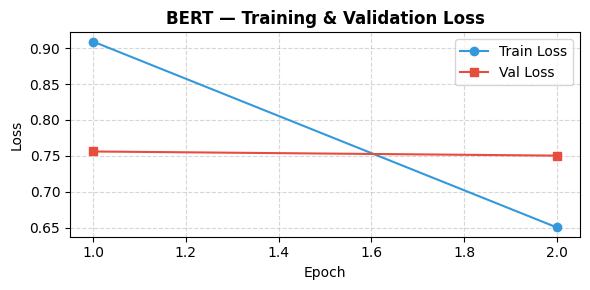


Evaluating BERT


Evaluating BERT:   0%|          | 0/63 [00:00<?, ?it/s]


BERT Results:
   Accuracy  : 0.6692
   Precision : 0.6673
   Recall    : 0.6692
   Macro-F1  : 0.6661
              precision    recall  f1-score   support

    Negative       0.68      0.79      0.73       666
     Neutral       0.57      0.52      0.54       666
    Positive       0.75      0.70      0.73       666

    accuracy                           0.67      1998
   macro avg       0.67      0.67      0.67      1998
weighted avg       0.67      0.67      0.67      1998



In [ ]:
print('Loading BERT tokenizer and model...')
bert_tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

bert_train_ds = build_dataset(train_df['clean_text'], train_df['label'], bert_tokenizer)
bert_test_ds = build_dataset(test_df['clean_text'],  test_df['label'],  bert_tokenizer)
bert_val_ds = build_dataset(val_df['clean_text'],   val_df['label'],   bert_tokenizer)

bert_train_loader = DataLoader(bert_train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=True)
bert_test_loader = DataLoader(bert_test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
bert_val_loader = DataLoader(bert_val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

bert_model = BertForSequenceClassification.from_pretrained(
    'bert-base-uncased', num_labels=NUM_LABELS
).to(DEVICE)

bert_optimizer = AdamW(bert_model.parameters(), lr=2e-5, weight_decay=0.01)
total_steps = len(bert_train_loader) * EPOCHS
bert_scheduler = get_linear_schedule_with_warmup(
    bert_optimizer,
    num_warmup_steps=int(0.1 * total_steps),
    num_training_steps=total_steps
)

print('\nTraining BERT')
bert_history = train_model(bert_model, bert_train_loader, bert_val_loader, bert_optimizer, bert_scheduler)
plot_loss(bert_history, 'BERT')

print('\nEvaluating BERT')
bert_results = evaluate_model(bert_model, bert_test_loader, 'BERT')

# Free BERT memory before loading RoBERTa
del bert_model
torch.cuda.empty_cache()

## Section 7: RoBERTa — Fine-tuning & Evaluation

Loading RoBERTa tokenizer and model...


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.out_proj.weight', 'classifier.dense.weight', 'classifier.dense.bias', 'classifier.out_proj.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Training RoBERTa...


Epoch 1/2 [Train]:   0%|          | 0/188 [00:00<?, ?it/s]

Epoch 1/2 [Val]:   0%|          | 0/31 [00:00<?, ?it/s]

  → Epoch 1 | Train Loss: 0.9415 | Val Loss: 0.7818


Epoch 2/2 [Train]:   0%|          | 0/188 [00:00<?, ?it/s]

Epoch 2/2 [Val]:   0%|          | 0/31 [00:00<?, ?it/s]

  → Epoch 2 | Train Loss: 0.7090 | Val Loss: 0.7597


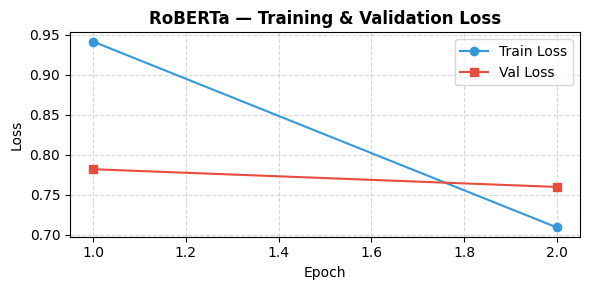


Evaluating RoBERTa...


Evaluating RoBERTa:   0%|          | 0/63 [00:00<?, ?it/s]


RoBERTa Results:
   Accuracy  : 0.6797
   Precision : 0.6718
   Recall    : 0.6797
   Macro-F1  : 0.6706
              precision    recall  f1-score   support

    Negative       0.70      0.83      0.76       666
     Neutral       0.60      0.46      0.52       666
    Positive       0.72      0.75      0.73       666

    accuracy                           0.68      1998
   macro avg       0.67      0.68      0.67      1998
weighted avg       0.67      0.68      0.67      1998



In [ ]:
print('Loading RoBERTa tokenizer and model...')
roberta_tokenizer = RobertaTokenizer.from_pretrained('roberta-base')

roberta_train_ds  = build_dataset(train_df['clean_text'], train_df['label'], roberta_tokenizer)
roberta_test_ds   = build_dataset(test_df['clean_text'],  test_df['label'],  roberta_tokenizer)
roberta_val_ds   = build_dataset(val_df['clean_text'],   val_df['label'],   roberta_tokenizer)

roberta_train_loader = DataLoader(roberta_train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=True)
roberta_test_loader = DataLoader(roberta_test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
roberta_val_loader = DataLoader(roberta_val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

roberta_model = RobertaForSequenceClassification.from_pretrained(
    'roberta-base', num_labels=NUM_LABELS
).to(DEVICE)

roberta_optimizer = AdamW(roberta_model.parameters(), lr=1e-5, weight_decay=0.01)
total_steps       = len(roberta_train_loader) * EPOCHS
roberta_scheduler = get_linear_schedule_with_warmup(
    roberta_optimizer,
    num_warmup_steps=int(0.1 * total_steps),
    num_training_steps=total_steps
)

print('Training RoBERTa...')
roberta_history = train_model(roberta_model, roberta_train_loader, roberta_val_loader, roberta_optimizer, roberta_scheduler)
plot_loss(roberta_history, 'RoBERTa')

print('\nEvaluating RoBERTa...')
roberta_results = evaluate_model(roberta_model, roberta_test_loader, 'RoBERTa')


del roberta_model
torch.cuda.empty_cache()

## Section 8: GPT-3 / BART — Few-Shot & Zero-Shot Classification


In [ ]:
from transformers import pipeline

# Free RoBERTa memory before loading BART
try:
    del roberta_model
    torch.cuda.empty_cache()
    print('RoBERTa memory cleared.')
except NameError:
    pass

# Load BART zero-shot classifier (free, no API key needed)
print('Loading BART zero-shot classifier...')
bart_classifier = pipeline(
    'zero-shot-classification',
    model='facebook/bart-large-mnli',
    device=0 if torch.cuda.is_available() else -1
)

candidate_labels = ['positive', 'negative', 'neutral']

def classify_sentiment_bart(text, mode='few_shot'):
    """
    Classify sentiment using BART zero-shot classification.
    mode: 'few_shot' adds a hypothesis template for better accuracy
    Returns: 0 (Negative), 1 (Neutral), 2 (Positive)
    """
    if mode == 'few_shot':
        # Richer hypothesis template simulates few-shot context
        hypothesis = 'The sentiment of this tweet is {}.'
        result = bart_classifier(
            text,
            candidate_labels,
            hypothesis_template=hypothesis
        )
    else:
        result = bart_classifier(text, candidate_labels)

    top_label = result['labels'][0].lower()
    if top_label == 'positive':  return 2
    elif top_label == 'negative': return 0
    else:                         return 1

print('BART classifier ready!')

Loading BART zero-shot classifier...
BART classifier ready!


In [ ]:
# Stratified sample for fair evaluation
bart_sample = test_df.groupby('label', group_keys=False).apply(
    lambda x: x.sample(min(len(x), GPT3_SAMPLE // NUM_LABELS), random_state=SEED)
).reset_index(drop=True)

bart_labels = bart_sample['label'].tolist()

# Few-shot mode
print(f'Running BART Few-Shot on {len(bart_sample)} samples...')
bart_fs_preds = [
    classify_sentiment_bart(text, mode='few_shot')
    for text in tqdm(bart_sample['clean_text'])
]

# Zero-shot mode
print(f'\nRunning BART Zero-Shot on {len(bart_sample)} samples...')
bart_zs_preds = [
    classify_sentiment_bart(text, mode='zero_shot')
    for text in tqdm(bart_sample['clean_text'])
]

# Evaluate both modes
bart_fs_results = compute_metrics(bart_labels, bart_fs_preds, 'BART Few-Shot (GPT-3 substitute)')
bart_zs_results = compute_metrics(bart_labels, bart_zs_preds, 'BART Zero-Shot (GPT-3 substitute)')

Running BART Few-Shot on 99 samples...


  0%|          | 0/99 [00:00<?, ?it/s]


Running BART Zero-Shot on 99 samples...


  0%|          | 0/99 [00:00<?, ?it/s]


BART Few-Shot (GPT-3 substitute):
Accuracy: 0.6061
Precision: 0.7366
Recall: 0.6061
Macro-F1: 0.4989
              precision    recall  f1-score   support

    Negative       0.58      0.97      0.73        33
     Neutral       1.00      0.03      0.06        33
    Positive       0.63      0.82      0.71        33

    accuracy                           0.61        99
   macro avg       0.74      0.61      0.50        99
weighted avg       0.74      0.61      0.50        99


BART Zero-Shot (GPT-3 substitute):
Accuracy: 0.5960
Precision: 0.3985
Recall: 0.5960
Macro-F1: 0.4762
              precision    recall  f1-score   support

    Negative       0.58      0.97      0.73        33
     Neutral       0.00      0.00      0.00        33
    Positive       0.61      0.82      0.70        33

    accuracy                           0.60        99
   macro avg       0.40      0.60      0.48        99
weighted avg       0.40      0.60      0.48        99



## Section 9: Results Comparison & Visualization

In [ ]:
results_df = pd.DataFrame({
    'Model'    : ['BERT', 'RoBERTa', 'BART (Few-Shot)', 'BART (Zero-Shot)'],
    'Accuracy' : [bert_results['accuracy'],    roberta_results['accuracy'],
                  bart_fs_results['accuracy'],  bart_zs_results['accuracy']],
    'Precision': [bert_results['precision'],   roberta_results['precision'],
                  bart_fs_results['precision'], bart_zs_results['precision']],
    'Recall'   : [bert_results['recall'],      roberta_results['recall'],
                  bart_fs_results['recall'],    bart_zs_results['recall']],
    'Macro-F1' : [bert_results['f1'],          roberta_results['f1'],
                  bart_fs_results['f1'],        bart_zs_results['f1']]
}).set_index('Model')

print('\nFinal Comparison Table')
print(results_df.round(4).to_string())


Final Comparison Table
                  Accuracy  Precision  Recall  Macro-F1
Model                                                  
BERT                0.6692     0.6673  0.6692    0.6661
RoBERTa             0.6797     0.6718  0.6797    0.6706
BART (Few-Shot)     0.6061     0.7366  0.6061    0.4989
BART (Zero-Shot)    0.5960     0.3985  0.5960    0.4762


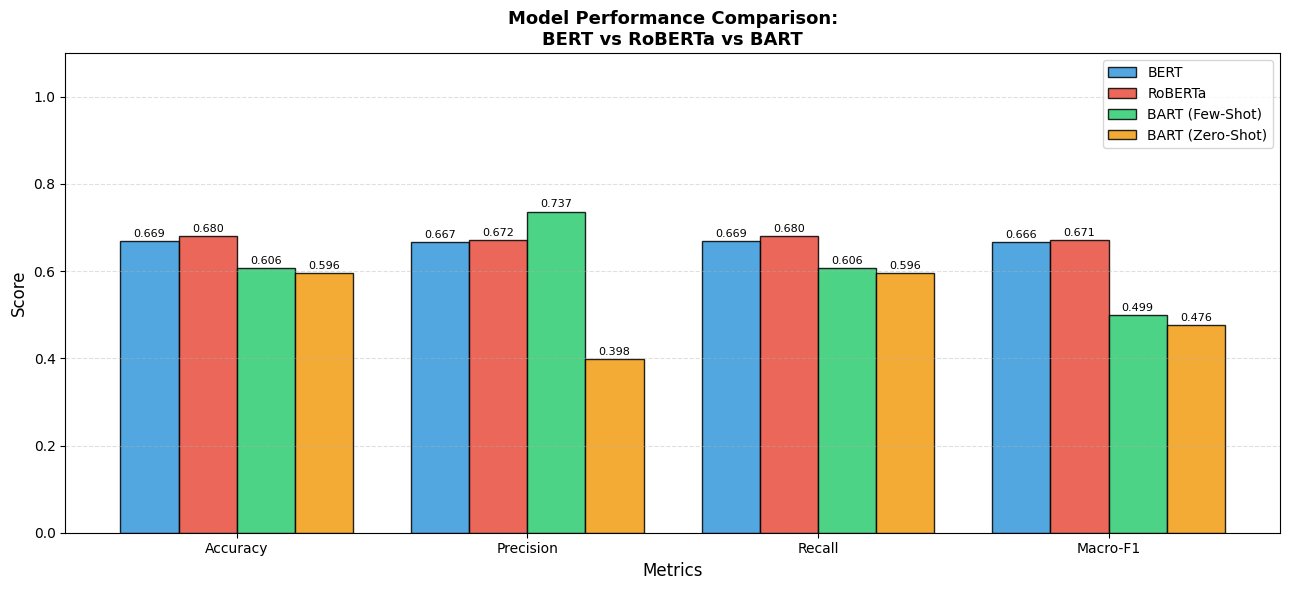

Bar chart saved.


In [ ]:
# Grouped bar chart
metrics = ['Accuracy', 'Precision', 'Recall', 'Macro-F1']
x       = np.arange(len(metrics))
width   = 0.20
colors  = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']

fig, ax = plt.subplots(figsize=(13, 6))
for i, (model, color) in enumerate(zip(results_df.index, colors)):
    bars = ax.bar(x + i * width, results_df.loc[model, metrics],
                  width, label=model, color=color, edgecolor='black', alpha=0.85)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.005,
                f'{bar.get_height():.3f}',
                ha='center', va='bottom', fontsize=8)

ax.set_xlabel('Metrics', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Model Performance Comparison:\nBERT vs RoBERTa vs BART',
             fontsize=13, fontweight='bold')
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.1)
ax.legend(loc='upper right')
ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150)
plt.show()
print('Bar chart saved.')

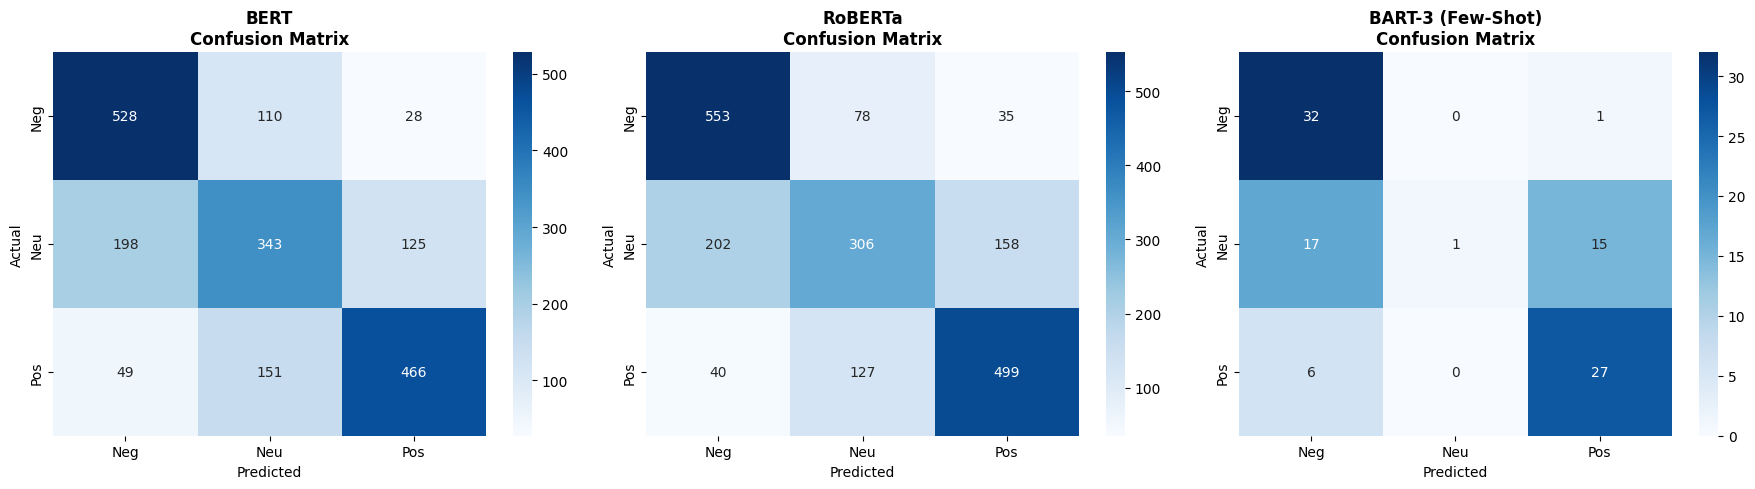

Confusion matrices saved.


In [ ]:
# Confusion matrices — BERT, RoBERTa, BART Few-Shot
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
plot_data = [
    ('BERT',             bert_results),
    ('RoBERTa',          roberta_results),
    ('BART-3 (Few-Shot)', bart_fs_results)
]

for ax, (name, res) in zip(axes, plot_data):
    cm = confusion_matrix(res['labels'], res['preds'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Neg','Neu','Pos'],
                yticklabels=['Neg','Neu','Pos'])
    ax.set_title(f'{name}\nConfusion Matrix', fontsize=12, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150)
plt.show()
print('Confusion matrices saved.')

## Section 10: Save Results

In [ ]:
# Save results table
results_df.round(4).to_csv('model_results.csv')
print('Results saved to model_results.csv')

print('\nFinal Summary:')
print(results_df.round(4).to_string())

Results saved to model_results.csv

Final Summary:
                  Accuracy  Precision  Recall  Macro-F1
Model                                                  
BERT                0.6692     0.6673  0.6692    0.6661
RoBERTa             0.6797     0.6718  0.6797    0.6706
BART (Few-Shot)     0.6061     0.7366  0.6061    0.4989
BART (Zero-Shot)    0.5960     0.3985  0.5960    0.4762


In [ ]:
# Mount Google Drive to save models permanently

# from google.colab import drive
# drive.mount('/content/drive')
# results_df.round(4).to_csv('/content/drive/MyDrive/model_results.csv')